In [10]:
pip install pandas numpy yfinance plotly scikit-learn ta streamlit

  Using cached ta-0.11.0-py3-none-any.whl
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------- ----------------------- 4.2/9.9 MB 23.4 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 25.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 18.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------------- -------- 6.3/8.0 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 20.3 MB/s  0:00:00
   ------------------

  You can safely remove it manually.


# AI Stock Analysis Exploration
# This notebook explores financial data and technical indicators
# used in the AI Stock Dashboard.

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = yf.download("AAPL", period="5y")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-03-17,121.515686,122.587080,119.158611,120.824150,111932600
2021-03-18,117.395683,119.976773,117.191145,119.684571,121229700
2021-03-19,116.869728,118.272284,116.567792,116.782072,185549500
2021-03-22,120.181313,120.648834,117.132709,117.200889,111912300
2021-03-23,119.353432,121.009221,118.963832,120.122889,95467100


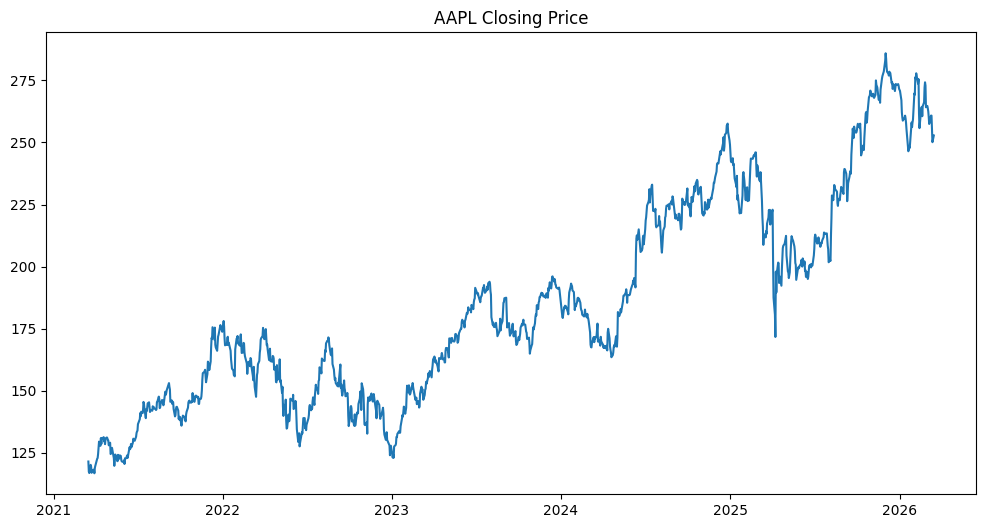

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.title("AAPL Closing Price")
plt.show()

In [11]:
from ta.momentum import RSIIndicator
from ta.trend import MACD

rsi = RSIIndicator(close=data["Close"])
data["RSI"] = rsi.rsi()

macd = MACD(close=data["Close"])
data["MACD"] = macd.macd()

ValueError: Data must be 1-dimensional, got ndarray of shape (1255, 1) instead

In [12]:
plt.figure(figsize=(12,5))
plt.plot(data["RSI"])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI Indicator")
plt.show()

KeyError: 'RSI'

<Figure size 1200x500 with 0 Axes>

In [13]:
from sklearn.ensemble import RandomForestRegressor

data["Target"] = data["Close"].shift(-7)

data = data.dropna()

X = data[["RSI","MACD"]]
y = data["Target"]

model = RandomForestRegressor()
model.fit(X,y)

KeyError: "['RSI' 'MACD'] not in index"

In [ ]:
prediction = model.predict(X.iloc[-1:])
print(prediction)